In [66]:
import os
import glob
import cv2
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from segmentation_models_pytorch import Unet
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [67]:
image_paths = sorted(glob.glob("images/*.tif"))
images = []

for path in image_paths:
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)  # grayscale
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX) # normalize the images
    img = img.astype(np.uint8) # for some reason there was an odd problem with the pretrained models so had to do this
    images.append((path, img))

In [68]:
transform = transforms.Compose([
    transforms.ToTensor(),  # [0,1]
])
def to_rgb_tensor(img):
    """Convert grayscale image to 3-channel RGB tensor"""
    img_rgb = np.stack([img]*3, axis=-1) # converting them to tensor and 3d
    return transform(img_rgb).unsqueeze(0).to(device)

In [69]:
model_unet = Unet( # pretrained unet
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3, # 3d input
    classes=1, # segment output
).to(device)
model_unet.eval()

model_deeplab = torchvision.models.segmentation.deeplabv3_resnet50().to(device)
model_deeplab.eval() # pretrained deeplabv3

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

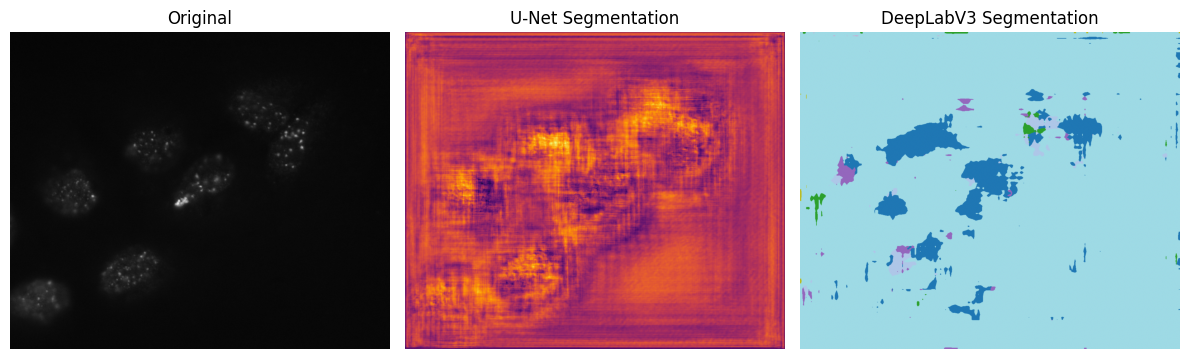

Saved results for im1


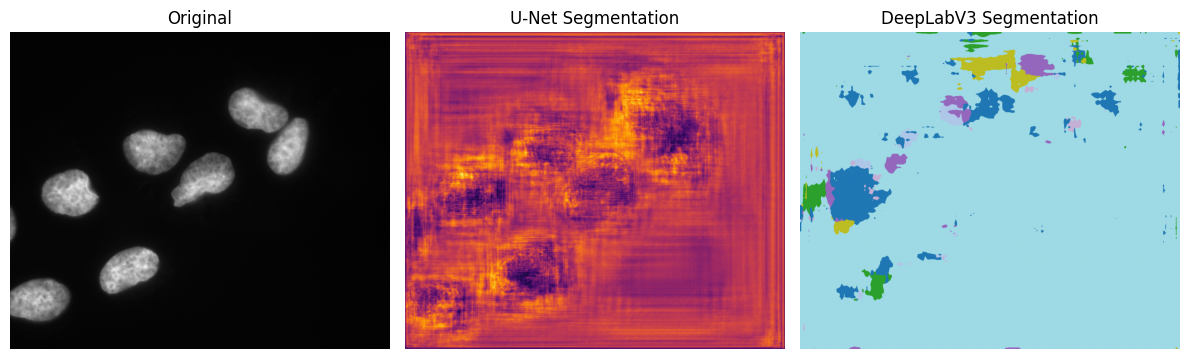

Saved results for im2


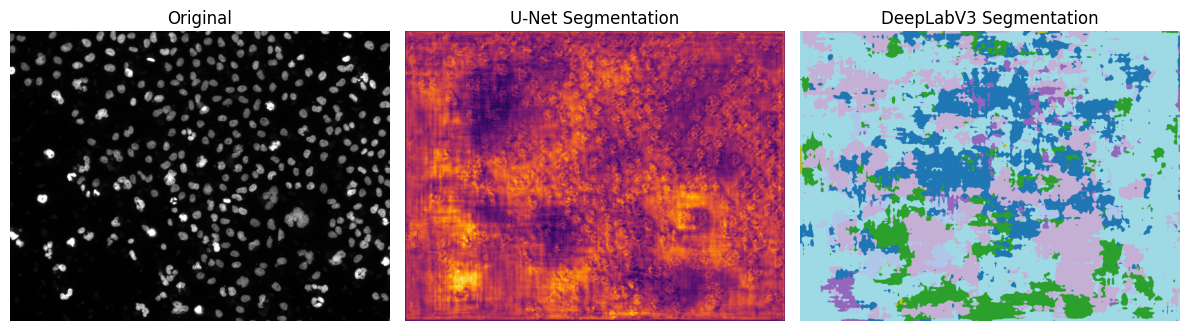

Saved results for im3


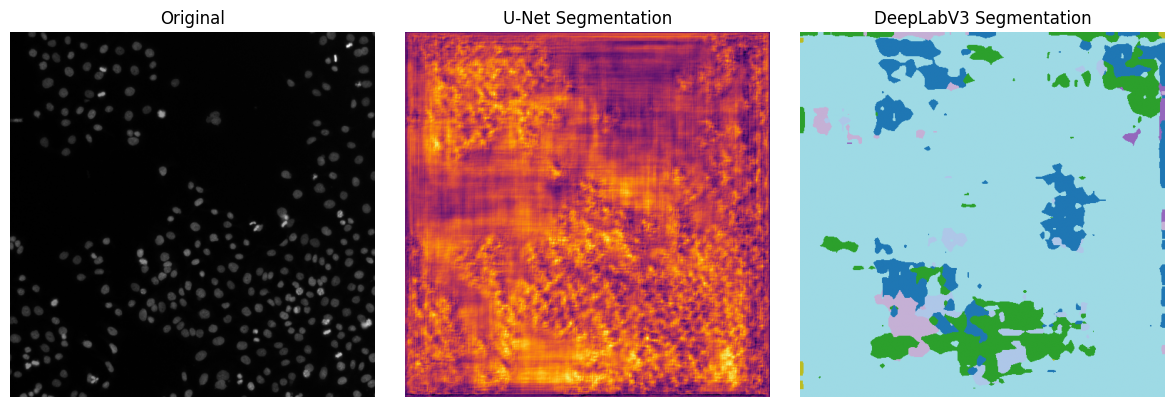

Saved results for im4


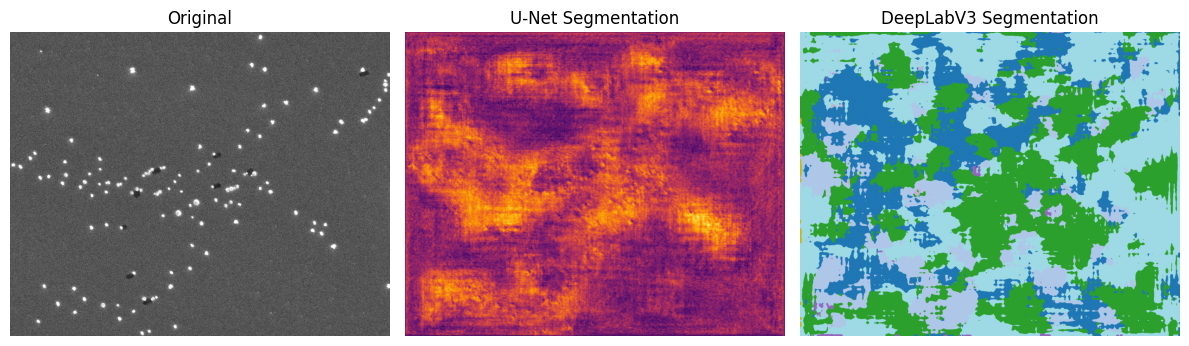

Saved results for image_1_


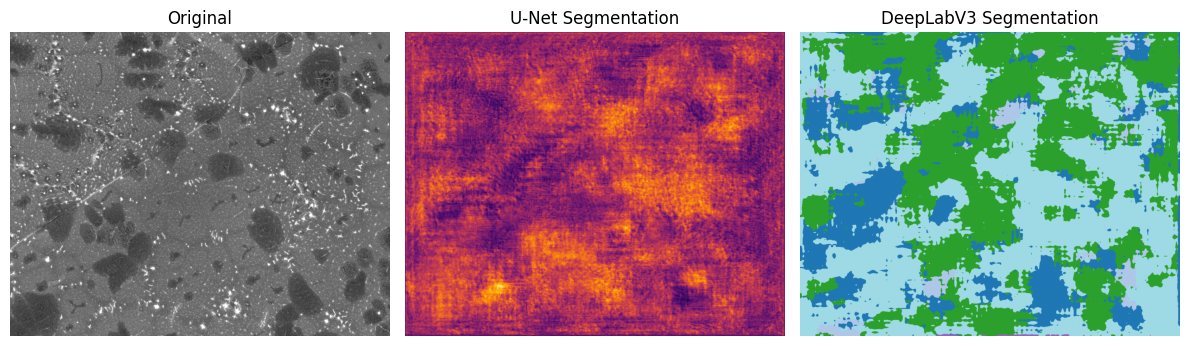

Saved results for image_2_


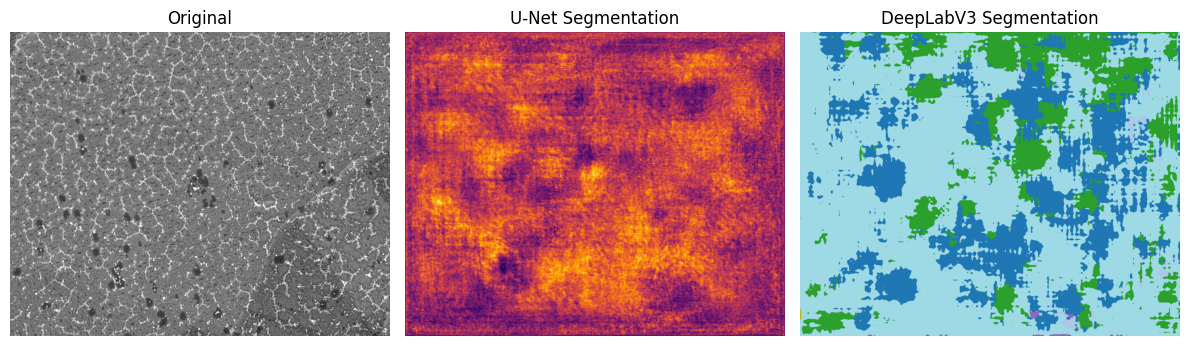

Saved results for image_3_


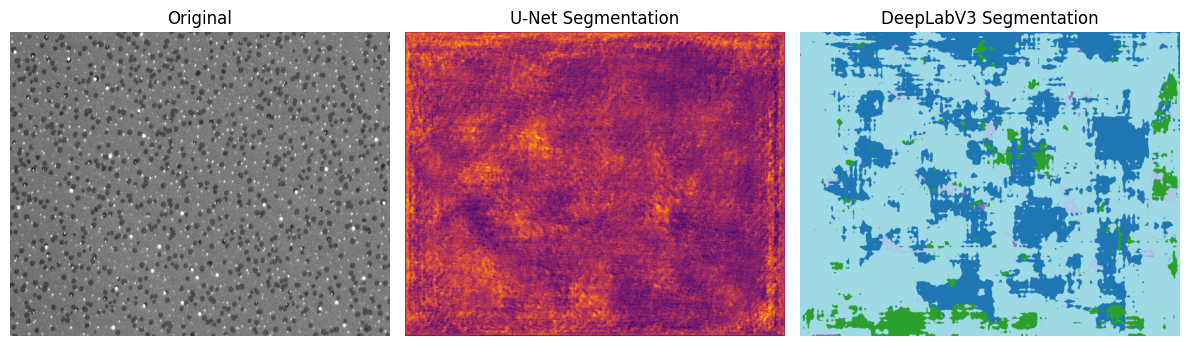

Saved results for image_4_


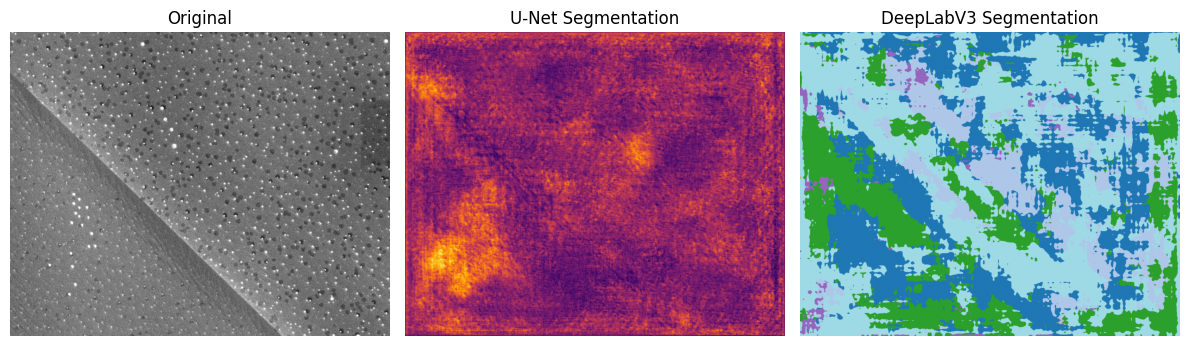

Saved results for image_5_


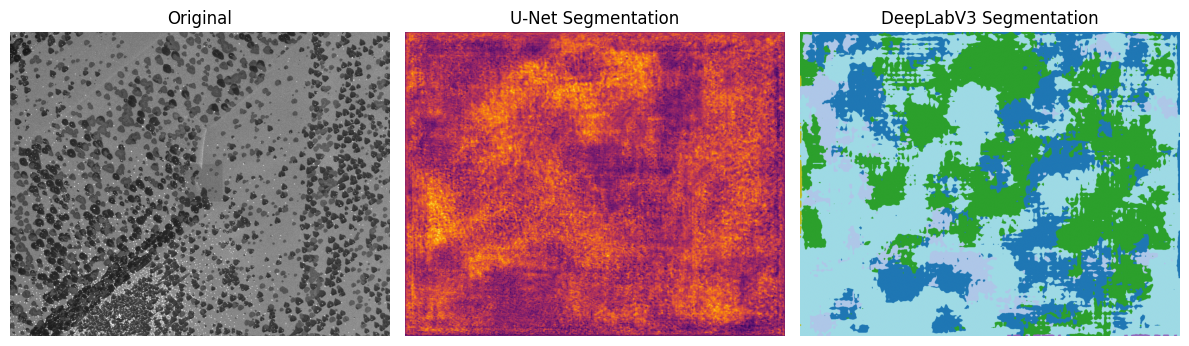

Saved results for image_6_


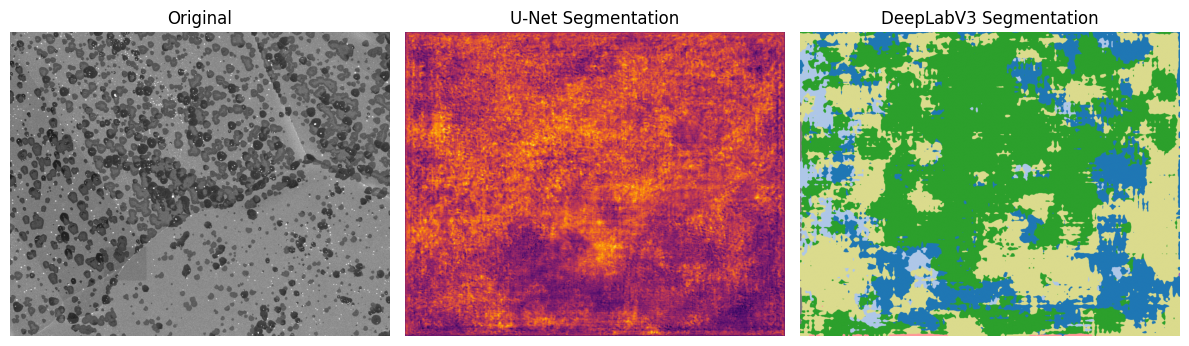

Saved results for image_7_


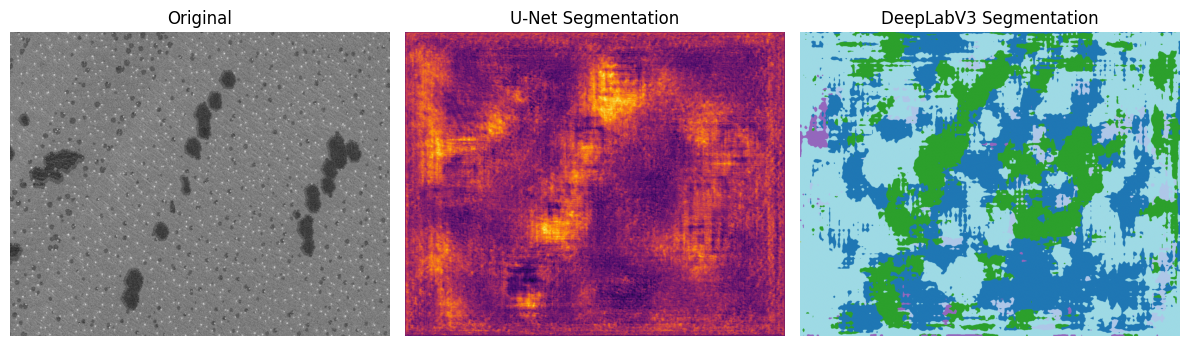

Saved results for image_8_


In [70]:
for i, (path, img) in enumerate(images):
    name = os.path.basename(path).replace(".tif", "")
    img_tensor = to_rgb_tensor(img) # conversion

    # U Net eval here
    with torch.no_grad():
        out_unet = model_unet(img_tensor)
        mask_unet = torch.sigmoid(out_unet)[0, 0].cpu().numpy()

    mask_unet_vis = (mask_unet * 255).astype(np.uint8) # un-normalizing the mask
    cv2.imwrite(f"results_unet/{name}_unet.png", mask_unet_vis)

    # lab v3 eval here
    with torch.no_grad():
        out_deeplab = model_deeplab(img_tensor)["out"]
        pred = torch.softmax(out_deeplab, dim=1)
        mask_deeplab = pred.argmax(dim=1)[0].cpu().numpy()

    mask_deeplab_vis = (mask_deeplab / mask_deeplab.max() * 255).astype(np.uint8) # un-normalizing
    cv2.imwrite(f"results_deeplab/{name}_deeplab.png", mask_deeplab_vis)

    # ------------------- Display -------------------
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask_unet, cmap='inferno')
    plt.title("U-Net Segmentation")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(mask_deeplab, cmap='tab20')
    plt.title("DeepLabV3 Segmentation")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Saved results for {name}")